#**스마트폰 센서 데이터 기반 모션 분류**
# 단계2 : 기본 모델링


## 0.미션3

* 데이터 전처리
    * 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리 수행
* 다양한 딥러닝 구조의 모델로 분류 모델 생성
    * 최소 4개 이상 모델링 수행
    * 각 모델별 최소 5회 반복수행해서 얻은 성능의 평균으로 비교
    * 각 모델의 성능을 저장하는 별도 데이터 프레임을 만들고 비교
* 옵션 : 다음 사항은 선택사항입니다. 시간이 허용하는 범위 내에서 수행하세요.
    * 상위 N개 변수를 선정하여 모델링 및 성능 비교
        * 모델링에 항상 모든 변수가 필요한 것은 아닙니다.
        * 변수 중요도 상위 N개를 선정하여 모델링하고 타 모델과 성능을 비교하세요.
        * 상위 N개를 선택하는 방법은, 변수를 하나씩 늘려가며 모델링 및 성능 검증을 수행하여 적절한 지점을 찾는 것입니다.
* 성능 가이드
    * Accuracy : 0.90 ~ 0.99

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
path = '/content/drive/MyDrive/Deep_Learning/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam

In [4]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='train_err', marker = '.')
    plt.plot(history.history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [5]:
# 학습 곡선 그리기 함수 수정
def dl_history_plot2(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker='.')
    plt.plot(history['val_loss'], label='val_err', marker='.')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

정확도 그래프 함수 생성

In [6]:
def plot_accuracy(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label='train_accuracy', marker='.')
    plt.plot(history.history['val_accuracy'], label='val_accuracy', marker='.')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [7]:
def plot_accuracy2(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['accuracy'], label='train_accuracy', marker='.')
    plt.plot(history['val_accuracy'], label='val_accuracy', marker='.')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [16]:
train_data = pd.read_csv(path + 'data01_train.csv')
test_data = pd.read_csv(path + 'data01_test.csv')
feature_data = pd.read_csv(path + 'features.csv')

In [17]:
drop_cols = 'subject'
train_data.drop(columns=drop_cols, inplace=True)
test_data.drop(columns=drop_cols, inplace=True)

#### 2) 기본 정보 조회

In [18]:
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [19]:
train_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [20]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


In [21]:
train_data.shape

(5881, 562)

## **2. 데이터 전처리**

* 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리를 수행한다.


### (1) 데이터 분할1 : x, y

* 세부 요구사항
    - x, y로 분할합니다.

NaN값 확인

In [22]:
nan_count = train_data.isna().sum()

nan_col = nan_count[nan_count>0]

print(nan_col)

Series([], dtype: int64)


In [23]:
target = 'Activity'

x = train_data.drop(columns=target, axis=1)
y = train_data.loc[:,target]

### (2) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [24]:
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x)

### (4) 데이터분할2 : train, validation

* 세부 요구사항
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

In [30]:
x_train, x_val, y_train, y_val = train_test_split(x_scaled, y, test_size=0.3, random_state=1)
#랜덤state는 일단 빼두고 상의하기

가변수화 필요 여부 확인

In [31]:
categorical_columns = train_data.select_dtypes(include=['object', 'category']).columns

# 범주형 열 출력
print("가변수화가 필요한 열(범주형):")
print(categorical_columns)

가변수화가 필요한 열(범주형):
Index(['Activity'], dtype='object')


### (3) Y 전처리
* integer encoding : LabelEncoder
* (필요시) one-hot encoding

In [32]:
encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.transform(y_val)

In [33]:
y_train_enc

array([0, 4, 1, ..., 0, 3, 2])

## **3. 기본 모델링**



* 세부 요구사항
    - 모델1 : Base line 모델
        * Hidden Layer 없이 모델 생성
    - 모델2 : 복잡한 모델 생성
        * 최소 5개 이상의 은닉층을 추가한 모델
    - 모델3 ~ n : 튜닝 모델
        * 학습률, epoch 등 조정
        * 모델2에 과적합을 방지하기 위한 규제 기법 추가
        * Accuracy 최대화 시키는 모델 생성하기
    - 각 모델은 최소 5번 반복수행해서 얻은 성능의 평균값을 기록

In [35]:
n1 = x_scaled.shape[1]

n1

561

### (1) 모델1 : Base line



In [36]:
baseline_acc = []

for _ in range(5):
    clear_session()

    model1 = Sequential([
        Dense(6, activation='softmax',input_shape=(n1,))])

    model1.compile(optimizer=Adam(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    # 모델 학습
    hi1 = model1.fit(x_train, y_train_enc, validation_split=0.2, epochs=50, verbose=0, batch_size=64)

    # 검증 데이터에 대한 예측값 도출
    y_pred1_proba = model1.predict(x_val)

    # 예측값을 클래스 라벨로 변환
    y_pred1 = np.argmax(y_pred1_proba, axis=1)

    # 정확도 계산
    val_accuracy1 = accuracy_score(y_val_enc, y_pred1)

    # 정확도를 리스트에 저장
    baseline_acc.append(val_accuracy1)

print('\n',baseline_acc)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

 [0.9563739376770538, 0.9569405099150141, 0.9580736543909348, 0.9552407932011332, 0.9586402266288951]


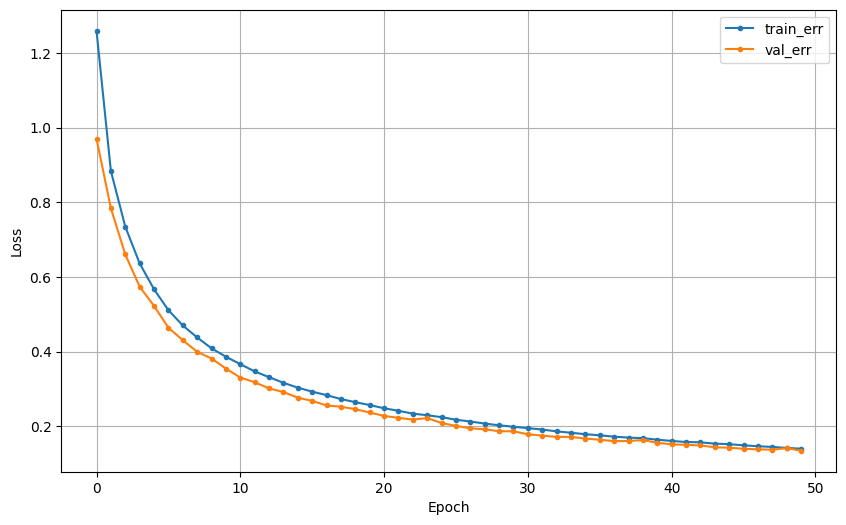

In [37]:
#손실 그래프
dl_history_plot(hi1)

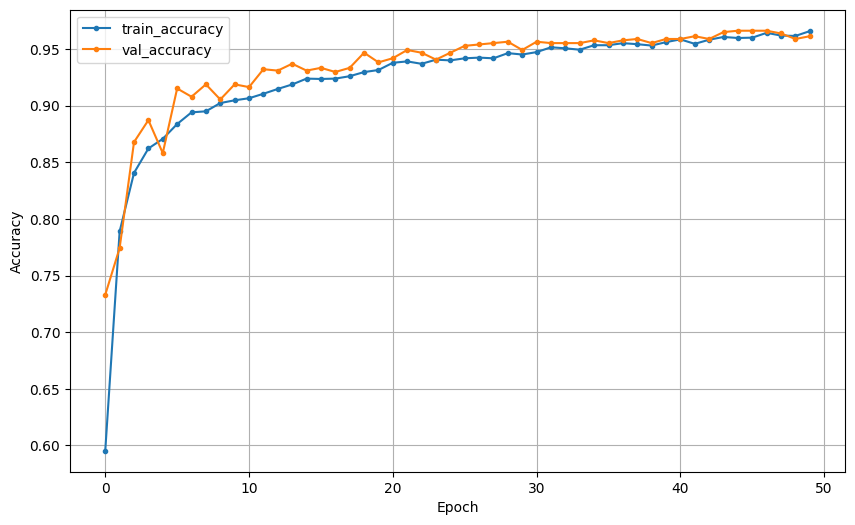

In [38]:
plot_accuracy(hi1)

In [39]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_enc, y_pred1))
print(confusion_matrix(y_val_enc, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       0.92      0.88      0.90       292
           2       0.90      0.93      0.92       331
           3       0.98      0.98      0.98       297
           4       0.98      0.98      0.98       239
           5       0.97      0.98      0.98       275

    accuracy                           0.96      1765
   macro avg       0.96      0.96      0.96      1765
weighted avg       0.96      0.96      0.96      1765

[[330   0   0   0   0   1]
 [  1 257  34   0   0   0]
 [  0  22 309   0   0   0]
 [  0   0   0 292   2   3]
 [  0   0   0   2 234   3]
 [  0   0   0   3   2 270]]


In [40]:
baseline_mean_acc = np.mean(baseline_acc)
baseline_std_acc = np.std(baseline_acc)
print(f'Basic Model 평균 : {baseline_mean_acc}')
print(f'Basic Model 표준편차 : {baseline_std_acc}')

Basic Model 평균 : 0.9570538243626062
Basic Model 표준편차 : 0.0012098672240261853


### (2) 모델2 : 5개 이상의 Hidden Layer 사용

In [41]:
complex_acc = []

for _ in range(5):
    clear_session()

    model2 = Sequential([
        Dense(256, activation='relu', input_shape=(n1,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(6, activation='softmax')  # 6개 클래스로 분류
    ])

    # 학습률
    model2.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # 모델 학습
    hi2 = model2.fit(x_train, y_train_enc, validation_split=0.2, epochs=50, verbose=1, batch_size=64)

    # 검증 데이터에 대한 예측값 도출
    y_pred2_proba = model2.predict(x_val)

    # 예측 값 클래스 라벨로 변환
    y_pred2 = np.argmax(y_pred2_proba, axis=1)

    # 정확도 계산
    val_accuracy2 = accuracy_score(y_val_enc, y_pred2)

    # 정확도 리스트에 저장
    complex_acc.append(val_accuracy2)

print('\n',complex_acc)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3300 - loss: 1.4508 - val_accuracy: 0.7609 - val_loss: 0.5972
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7456 - loss: 0.5459 - val_accuracy: 0.8204 - val_loss: 0.3836
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8392 - loss: 0.3981 - val_accuracy: 0.8823 - val_loss: 0.2771
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8862 - loss: 0.2988 - val_accuracy: 0.8944 - val_loss: 0.2475
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9204 - loss: 0.2081 - val_accuracy: 0.9417 - val_loss: 0.1701
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9392 - loss: 0.1515 - val_accuracy: 0.9515 - val_loss: 0.1066
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9612 - loss: 0.1106 - val_accuracy: 0.9551 - val_loss: 0.1249
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9611 - loss: 0.1066 - val_accuracy: 0.9672 - val_loss: 0.0846

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3245 - loss: 1.3323 - val_accuracy: 0.4624 - val_loss: 0.8832
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5994 - loss: 0.7456 - val_accuracy: 0.6954 - val_loss: 0.5302
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7563 - loss: 0.4744 - val_accuracy: 0.7718 - val_loss: 0.4383
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8842 - loss: 0.2935 - val_accuracy: 0.8167 - val_loss: 0.4408
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9019 - loss: 0.2670 - val_accuracy: 0.9466 - val_loss: 0.1631
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9266 - loss: 0.1961 - val_accuracy: 0.9551 - val_loss: 0.1085
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9528 - loss: 0.1312 - val_accuracy: 0.9539 - val_loss: 0.1516
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9485 - loss: 0.1496 - val_accuracy: 0.9660 - val_loss: 0.09

...

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3016 - loss: 1.5241 - val_accuracy: 0.4745 - val_loss: 0.9896
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5138 - loss: 0.9307 - val_accuracy: 0.5959 - val_loss: 0.7560
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7034 - loss: 0.5847 - val_accuracy: 0.5983 - val_loss: 0.9454
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7434 - loss: 0.5856 - val_accuracy: 0.8022 - val_loss: 0.4836
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8489 - loss: 0.4151 - val_accuracy: 0.9005 - val_loss: 0.3060
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8947 - loss: 0.2662 - val_accuracy: 0.9515 - val_loss: 0.1781
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9277 - loss: 0.2023 - val_accuracy: 0.9393 - val_loss: 0.1565
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9412 - loss: 0.1552 - val_accuracy: 0.9587 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2812 - loss: 1.6304 - val_accuracy: 0.6214 - val_loss: 0.9220
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5914 - loss: 0.9205 - val_accuracy: 0.6820 - val_loss: 0.7580
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6835 - loss: 0.7102 - val_accuracy: 0.7670 - val_loss: 0.5947
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7041 - loss: 0.6714 - val_accuracy: 0.7585 - val_loss: 0.5384
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7898 - loss: 0.5318 - val_accuracy: 0.7913 - val_loss: 0.4092
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8675 - loss: 0.3727 - val_accuracy: 0.8883 - val_loss: 0.3277
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8881 - loss: 0.3196 - val_accuracy: 0.9381 - val_loss: 0.2601
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9217 - loss: 0.2555 - val_accuracy: 0.8762 - val_loss: 0.3526
Epo

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3712 - loss: 1.3785 - val_accuracy: 0.5728 - val_loss: 0.7808
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6857 - loss: 0.6775 - val_accuracy: 0.8568 - val_loss: 0.3843
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8367 - loss: 0.3822 - val_accuracy: 0.8968 - val_loss: 0.2314
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8758 - loss: 0.3062 - val_accuracy: 0.9187 - val_loss: 0.2045
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9228 - loss: 0.2051 - val_accuracy: 0.9454 - val_loss: 0.1520
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9352 - loss: 0.1626 - val_accuracy: 0.9260 - val_loss: 0.2125
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9002 - loss: 0.2611 - val_accuracy: 0.9515 - val_loss: 0.1323
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9549 - loss: 0.1278 - val_accuracy: 0.9502 - val_loss: 0.1390

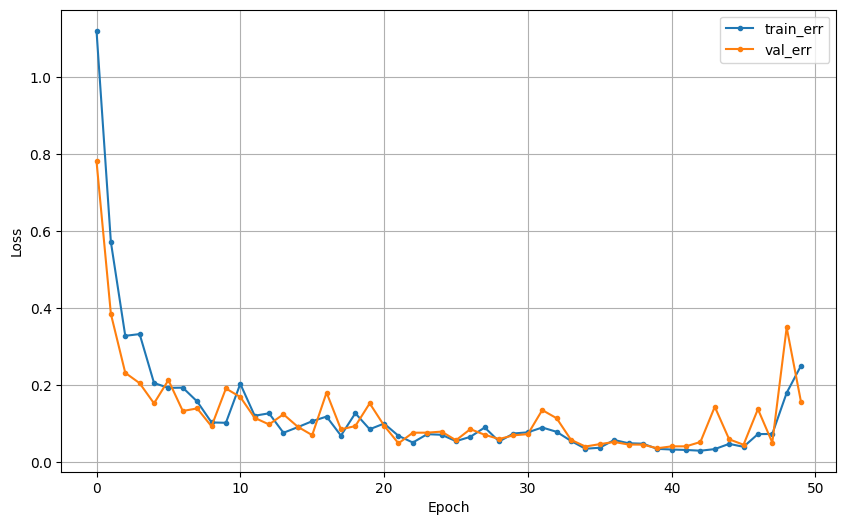

In [42]:
dl_history_plot(hi2)

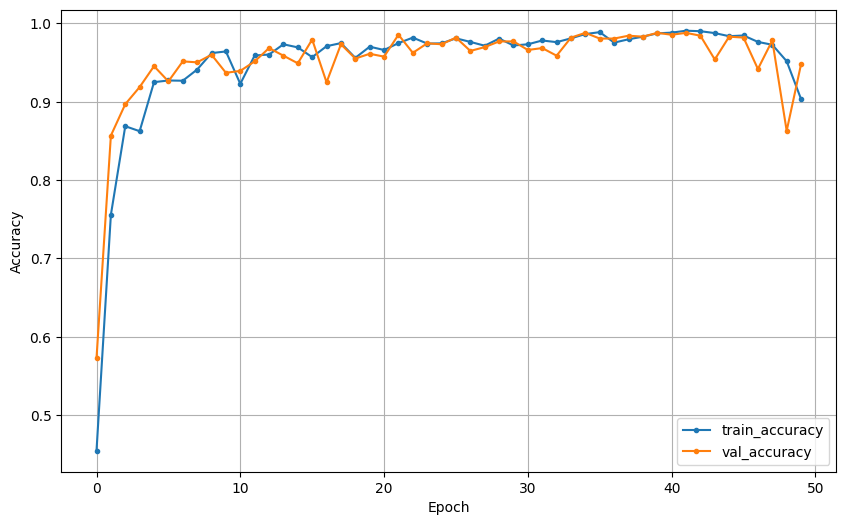

In [43]:
plot_accuracy(hi2)

In [44]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_enc, y_pred2))
print(confusion_matrix(y_val_enc, y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       331
           1       0.69      1.00      0.81       292
           2       1.00      0.64      0.78       331
           3       0.99      1.00      0.99       297
           4       1.00      0.99      0.99       239
           5       0.99      0.99      0.99       275

    accuracy                           0.92      1765
   macro avg       0.94      0.93      0.92      1765
weighted avg       0.94      0.92      0.92      1765

[[316  15   0   0   0   0]
 [  0 291   1   0   0   0]
 [  0 118 213   0   0   0]
 [  0   0   0 296   0   1]
 [  0   0   0   1 236   2]
 [  0   0   0   2   0 273]]


In [45]:
# 평균과 표준편차 계산
complex_mean_acc = np.mean(complex_acc)
complex_std_acc = np.std(complex_acc)
print(f'Complex Model 평균 : {complex_mean_acc}')
print(f'Complex Model 표준편차 : {complex_std_acc}')

Complex Model 평균 : 0.9661189801699717
Complex Model 표준편차 : 0.02286426116111015


### (3)모델3 : Dropout 사용(실패)

In [46]:
tuned_acc_f = []
for _ in range(5):
    clear_session()

    model3_1 = Sequential([
        Dense(256, activation='relu',input_shape=(n1,)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(6,activation='softmax')
    ])

    model3_1.compile(optimizer=Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    hi3_1 = model3_1.fit(x_train,y_train_enc,validation_split=0.2,epochs=100,batch_size=64,verbose=0)

    y_pred3_1_proba = model3_1.predict(x_val)

    y_pred3_1 = np.argmax(y_pred3_1_proba,axis=1)

    val_acc3_1 = accuracy_score(y_val_enc,y_pred3_1)

    tuned_acc_f.append(val_acc3_1)

print('\n',tuned_acc_f)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [ ]:
dl_history_plot(hi3_1)

In [ ]:
plot_accuracy(hi3_1)

In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_enc, y_pred3_1))
print(confusion_matrix(y_val_enc, y_pred3_1))

In [ ]:
tuned_mean_acc_f = np.mean(tuned_acc_f)
tuned_std_acc_f = np.std(tuned_acc_f)
print(f'Tuned Model 평균 : {tuned_mean_acc_f}')
print(f'Tuend Model 표준편차 : {tuned_std_acc_f}')

###(3) 모델3: Dropout 사용 성공

In [48]:
tuned_acc = []
for _ in range(5):
    clear_session()

    model3 = Sequential([
        Dense(256, activation='relu',input_shape=(n1,)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(6,activation='softmax')
    ])

    model3.compile(optimizer=Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    hi3 = model3.fit(x_train,y_train_enc,validation_split=0.2,epochs=100,batch_size=64,verbose=0)

    y_pred3_proba = model3.predict(x_val)

    y_pred3 = np.argmax(y_pred3_proba,axis=1)

    val_acc3 = accuracy_score(y_val_enc,y_pred3)

    tuned_acc.append(val_acc3)

print('\n',tuned_acc)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [ ]:
dl_history_plot(hi3)

In [ ]:
plot_accuracy(hi3)

In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_enc, y_pred3))
print(confusion_matrix(y_val_enc, y_pred3))

In [ ]:
tuned_mean_acc = np.mean(tuned_acc)
tuned_std_acc = np.std(tuned_acc)
print(f'Tuned Model 평균 : {tuned_mean_acc}')
print(f'Tuend Model 표준편차 : {tuned_std_acc}')

### (4)모델 4: SlmpleRNN

In [ ]:
# 데이터 RNN 입력 형태로 변환
x_train_rnn = x_train.reshape((x_train.shape[0],x_train.shape[1],1))
x_val_rnn = x_val.reshape((x_val.shape[0],x_val.shape[1],1))

In [ ]:
n2 = x_train_rnn.shape[1]

In [ ]:
from keras.layers import SimpleRNN
from keras.callbacks import EarlyStopping

simplernn_acc = []

# EarlyStopping 설정 (검증 손실이 5 에포크 동안 개선되지 않으면 학습 중단)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for _ in range(5):
    clear_session()

    # SimpleRNN 모델 정의
    model4 = Sequential([
        SimpleRNN(64, activation='relu', input_shape=(n2, 1), return_sequences=True),
        SimpleRNN(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(6, activation='softmax')
    ])

    model4.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # 모델 학습 (EarlyStopping 콜백 추가)
    hi4 = model4.fit(x_train_rnn, y_train_enc, validation_split=0.2, epochs=100, verbose=0,
                     callbacks=[early_stopping]).history

    # 검증 데이터에 대한 예측값 도출
    y_pred = model4.predict(x_val_rnn)

    # 예측값을 클래스 라벨로 변환
    y_pred_1 = np.argmax(y_pred, axis=1)

    # 정확도 계산
    val_accuracy = accuracy_score(y_val_enc, y_pred_1)

    # 정확도 리스트에 저장
    simplernn_acc.append(val_accuracy)

print(simplernn_acc)

In [ ]:
dl_history_plot2(hi4)

In [ ]:
plot_accuracy2(hi4)

In [ ]:
simplernn_mean_acc = np.mean(simplernn_acc)
simplernn_std_acc = np.std(simplernn_acc)
print(f'SimpleRNN Model 평균 : {simplernn_mean_acc}')
print(f'SimpleRNN Model 표준편차 : {simplernn_std_acc}')

### (5)모델5: LSTM

In [ ]:
from keras.layers import LSTM

lstm_acc = []

for _ in range(5):

    clear_session()

    model5 = Sequential([
        LSTM(64, activation='relu',input_shape=(n2,1),return_sequences=True),
        LSTM(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(6,activation='softmax')
    ])

    model5.compile(optimizer=Adam(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    hi5 = model5.fit(x_train, y_train_enc, validation_split=0.2,epochs=100,verbose=0,
                     callbacks=[early_stopping]).history

    y_pred5_proba = model5.predict(x_val)

    y_pred5 = np.argmax(y_pred5_proba, axis=1)

    val_acc5 = accuracy_score(y_val_enc,y_pred5)

    lstm_acc.append(val_acc5)

print('\n',lstm_acc)

In [ ]:
dl_history_plot2(hi5)

In [ ]:
plot_accuracy2(hi5)

In [ ]:
# 평균과 표준편차 계산
lstm_mean_acc = np.mean(lstm_acc)
lstm_std_acc = np.std(lstm_acc)
print(f'Complex Model 평균 : {lstm_mean_acc}')
print(f'Complex Model 표준편차 : {lstm_std_acc}')

### (6)모델 6: GRU

In [ ]:
from keras.layers import GRU
from keras.regularizers import l1,l2,l1_l2
gru_acc = []

for _ in range(5):

    clear_session()

    model6 = Sequential([
        GRU(64, activation='relu', input_shape=(n2,1), return_sequences=True,
             kernel_regularizer =l1_l2(l1=0.01,l2=0.01)),
        GRU(64,activation='relu',kernel_regularizer =l1_l2(l1=0.01,l2=0.01)),
        Dropout(0.2),
        Dense(32,activation='relu',kernel_regularizer =l1_l2(l1=0.01,l2=0.01)),
        Dense(16,activation='relu',kernel_regularizer =l1_l2(l1=0.01,l2=0.01)),
        Dense(6,activation='softmax')
    ])

    model6.compile(optimizer=Adam(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    hi6 = model6.fit(x_train, y_train_enc, validation_split=.2,epochs=100,
                     callbacks=[early_stopping]).history

    y_pred6_proba = model6.predict(x_val)

    y_pred6 = np.argmax(y_pred6_proba, axis=1)

    val_acc6 = accuracy_score(y_val_enc,y_pred6)

    gru_acc.append(val_acc6)
print('\n',gru_acc)

In [ ]:
dl_history_plot2(hi6)

In [ ]:
plot_accuracy2(hi6)

In [ ]:
# 평균과 표준편차 계산
gru_mean_acc = np.mean(gru_acc)
gru_std_acc = np.std(gru_acc)
print(f'Complex Model 평균 : {gru_mean_acc}')
print(f'Complex Model 표준편차 : {gru_std_acc}')

### (7)모델 7 : EarlyStopping and LessDense

In [ ]:
early_acc = []
for _ in range(5):
    clear_session()

    model7 = Sequential([
        Dense(64, activation='relu',input_shape=(n1,)),
        Dense(6,activation='softmax')
    ])

    model7.compile(optimizer=Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    min_de=0.001
    pat=15

    es = EarlyStopping(monitor = 'val_loss', min_delta = min_de, patience = pat)

    hi7 = model7.fit(x_train,y_train_enc,validation_split=0.2,epochs=100,batch_size=64,verbose=0, callbacks=[es])

    y_pred7_proba = model7.predict(x_val)

    y_pred7 = np.argmax(y_pred7_proba,axis=1)

    val_acc7 = accuracy_score(y_val_enc,y_pred7)

    early_acc.append(val_acc7)

print('\n',early_acc)

In [ ]:
dl_history_plot(hi7)

In [ ]:
plot_accuracy(hi7)

In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_enc, y_pred7))
print(confusion_matrix(y_val_enc, y_pred7))

In [ ]:
early_mean_acc = np.mean(early_acc)
early_std_acc = np.std(early_acc)
print(f'Tuned Model 평균 : {early_mean_acc}')
print(f'Tuend Model 표준편차 : {early_std_acc}')

## 4.성능비교

* 세부 요구사항
    - test 데이터에 대한 전처리
    - 각 모델에 대해서 test 데이터로 성능 측정

In [ ]:
# Test 데이터 전처리
x_test = test_data.drop(target,axis=1)
y_test = test_data[target]

x_test_s = scaler.transform(x_test)

y_test_enc = encoder.transform(y_test)

In [ ]:
# 테스트 데이터 3차원 변환 (samples, timesteps, features)
# timesteps = 1로 설정
x_test_rnn = x_test_s.reshape((x_test_s.shape[0], 1, x_test_s.shape[1]))

In [ ]:
# RNN 모델 생성
model4 = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(1, x_train.shape[1]), return_sequences=True),
    SimpleRNN(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')
])

model4.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# LSTM 모델 생성
model5 = Sequential([
    LSTM(64, activation='relu', input_shape=(1, x_train.shape[1]), return_sequences=True),
    LSTM(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')
])

model5.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# GRU 모델 생성
model6 = Sequential([
    GRU(64, activation='relu', input_shape=(1, x_train.shape[1]), return_sequences=True),
    GRU(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')
])

model6.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 1. BaseLine Model
y_pred_baseline_proba = model1.predict(x_test_s)
y_pred_baseline = np.argmax(y_pred_baseline_proba, axis=1)
baseline_test_acc = accuracy_score(y_test_enc,y_pred_baseline)

# 2. Complex Model
y_pred_complex_proba = model2.predict(x_test_s)
y_pred_complex = np.argmax(y_pred_complex_proba, axis=1)
complex_test_acc = accuracy_score(y_test_enc,y_pred_complex)

# 3. Tuned Model
y_pred_tuned_proba = model3.predict(x_test_s)
y_pred_tuned = np.argmax(y_pred_tuned_proba, axis=1)
tuned_test_acc = accuracy_score(y_test_enc,y_pred_tuned)

# 4. SimpleRNN Model
y_pred_simplernn_proba = model4.predict(x_test_rnn)
y_pred_simplernn = np.argmax(y_pred_simplernn_proba, axis=1)
simplernn_test_acc = accuracy_score(y_test_enc, y_pred_simplernn)

# 5. LSTM Model
y_pred_lstm_proba = model5.predict(x_test_rnn)
y_pred_lstm = np.argmax(y_pred_lstm_proba, axis=1)
lstm_test_acc = accuracy_score(y_test_enc, y_pred_lstm)

# 6. GRU Model
y_pred_gru_proba = model6.predict(x_test_rnn)
y_pred_gru = np.argmax(y_pred_gru_proba, axis=1)
gru_test_acc = accuracy_score(y_test_enc, y_pred_gru)

# 6. GRU Model
y_pred_gru_proba = model6.predict(x_test_rnn)
y_pred_gru = np.argmax(y_pred_gru_proba, axis=1)
gru_test_acc = accuracy_score(y_test_enc, y_pred_gru)


print(f'BaseLine Model 테스트 정확도 : {baseline_test_acc}')
print(f'Complex Model  테스트 정확도 : {complex_test_acc}')
print(f'Tuned Model  테스트 정확도 : {tuned_test_acc}')
print(f'SimpleRNN Model 테스트 정확도 : {simplernn_test_acc}')
print(f'LSTM Model 테스트 정확도 : {lstm_test_acc}')
print(f'GRU Model 테스트 정확도 : {gru_test_acc}')